In [1]:
import cupy as xp
import numpy as np
import matplotlib.pyplot as plt

from ekarus.e2e.single_stage_ao_class import SingleStageAO
from ekarus.e2e.utils.image_utils import remap_on_new_mask, reshape_on_mask, get_circular_mask, get_photocenter, image_grid

import ekarus.e2e.utils.my_fits_package as my_fits

from numpy.ma import masked_array


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 4060 Laptop GPU`
       Memory = 7805.56 MB | Compute Capability = 8.9
       Using CuPy 13.5.1 for acceleration.


In [2]:
IFs = my_fits.read_fits('/home/matte/Downloads/DM468_iffs.fits').T
mask = my_fits.read_fits('/home/matte/Downloads/DM468_mask.fits',isBool=True)

Text(0.5, 1.0, 'Stiffness [$V/\\mu m$]\n')

<Figure size 640x480 with 0 Axes>

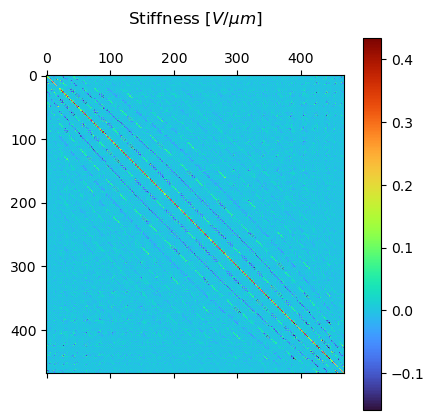

In [3]:
IFs_norm = IFs - xp.mean(IFs,axis=0)
max_if_ids = xp.argmax(IFs,axis=0)

C = IFs_norm[max_if_ids,:]

K = xp.linalg.pinv(C,rcond=0.05)

plt.figure()
plt.matshow(K.get()/1e+6,cmap='turbo')
plt.colorbar()
plt.title(r'Stiffness [$V/\mu m$]'+'\n')

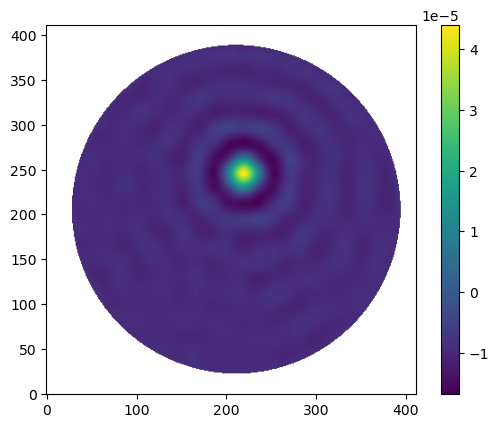

In [4]:

c1 = xp.zeros(468)
c1[200] = 1e-4
c1 = K @ c1

shape = IFs @ c1
img = reshape_on_mask(shape,mask)

plt.figure()
plt.imshow(masked_array(img.get(),mask=mask.get()),origin='lower')
plt.colorbar()

In [5]:
def get_slaving_mat(IF,K,zero_force:bool=False,thr:float=0.2):   
    thr = thr*xp.max(IF)
    slave_ids = xp.where(xp.max(IF,axis=0)<thr)[0]
    master_ids = xp.where(xp.max(IF,axis=0)>=thr)[0]

    Kss = K[slave_ids][:,slave_ids]
    Ksm = K[slave_ids][:,master_ids]
    Kms = K[master_ids][:,slave_ids]
    Kmm = K[master_ids][:,master_ids]

    if zero_force:
        Qs = -xp.linalg.pinv(Kss) @ Ksm
    else:
        Qs = -xp.linalg.pinv(Kms.T @ Kms + Kss.T @ Kss) @ (Kms.T @ Kmm + Kss.T @ Ksm)

    # Slaved matrices
    IF = IF @ K
    IFslaved = IF[:,master_ids] + IF[:,slave_ids] @ Qs 
    Kslaved = Kmm + Kms @ Qs    
    
    nActs = len(master_ids)+len(slave_ids)
    m2c = xp.eye(nActs)[:,master_ids]
    for k,id in enumerate(slave_ids):
        m2c[id,:] += Qs[k,:]

    return IFslaved, m2c


def get_tikho_slaving(IF,thr:float=1e-4):
    U,S,Vt = xp.linalg.svd(IF,full_matrices=False)
    plt.figure()
    plt.loglog(np.arange(len(S))+1,xp.asnumpy(S),'--o')
    plt.loglog(xp.asnumpy(thr*max(S)*xp.ones(len(S)*10)),'--')
    Sinv = S/(S**2 + (thr*xp.max(S))**2)
    Rec = (Vt.T * Sinv) @ U.T
    plt.loglog(np.arange(len(S))+1,xp.asnumpy(1/Sinv),'--o')
    plt.grid(which='both',alpha=0.3)
    return Rec


def specula_slaving(IF,coordinates,step:float,slaving_thr:float=0.2):

    max_vals = xp.max(IF, axis=0)
    max_vals_all = xp.max(IF)
    idx_master = xp.where(max_vals >= slaving_thr * max_vals_all)[0]
    idx_slave = xp.where(max_vals < slaving_thr * max_vals_all)[0]

    plt.figure()
    plt.scatter(xp.asnumpy(coordinates[0]),xp.asnumpy(coordinates[1]),c='green',label='masters')
    plt.scatter(xp.asnumpy(coordinates[0,idx_slave]),xp.asnumpy(coordinates[1,idx_slave]),c='red',label='slaves')
    plt.legend()
    plt.grid()
    plt.axis('equal')

    n_act_tot = xp.shape(IF)[1]
    iffs = IF.T.copy()

    slaveMat1 = xp.zeros([n_act_tot, n_act_tot])

    for i in range(n_act_tot):
        if i in idx_master:
            distance = xp.sqrt((coordinates[0] - coordinates[0][i])**2 + 
                            (coordinates[1] - coordinates[1][i])**2)

            idx_close_master1 = xp.where(distance <= 1.1 * step)[0]
            idx_close_master1 = xp.intersect1d(idx_close_master1, idx_slave)

            if len(idx_close_master1) > 0:
                for j in idx_close_master1:
                    slaveMat1[i, j] = 1.0

    for j in range(n_act_tot):
        slaveMat1[:, j] *= 1.0 / max(1.0, xp.sum(slaveMat1[:, j]))

    for i in range(n_act_tot):
        if xp.sum(slaveMat1[i, :]) > 0:
            idx_temp = xp.where(slaveMat1[i, :] > 0)[0]
            for j in idx_temp:
                iffs[i] += slaveMat1[i, j] * iffs[j]

    aux = xp.zeros([n_act_tot, n_act_tot])#slaveMat1.copy()
    for i in range(n_act_tot):
        if i in idx_master:
            aux[i,i] = 1.0
    m2c = aux[idx_master,:]#xp.linalg.pinv(slaveMat1[idx_master,:])

    iffs = iffs[idx_master]

    return iffs.T, m2c.T

In [6]:
xx,yy = image_grid(mask.shape)

valid_indices = xp.where(~mask.ravel())[0]
act_ids = valid_indices[max_if_ids]

act_coords = xp.array([xx.flatten()[act_ids],yy.flatten()[act_ids]])
print(act_coords.shape)

(2, 468)


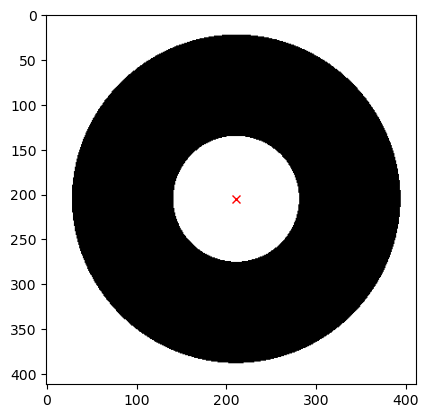

In [7]:
cx,cy = get_photocenter((1-mask).astype(float))

robs = 70

obs_mask = xp.logical_or(mask,1-get_circular_mask(mask.shape, mask_radius=robs, mask_center=(cx,cy)))

plt.figure()
plt.imshow(obs_mask.get(),cmap='gray')
plt.plot(cx.get(),cy.get(),'x',c='red')

In [8]:
sIF = xp.zeros([int(xp.sum(1-obs_mask)),xp.shape(IFs)[1]])

for i in range(int(xp.shape(IFs)[1])):
    sIF[:,i] = reshape_on_mask(IFs[:,i],mask)[~obs_mask]

(89514, 440) (89514, 440) (89514, 440) (468, 440)


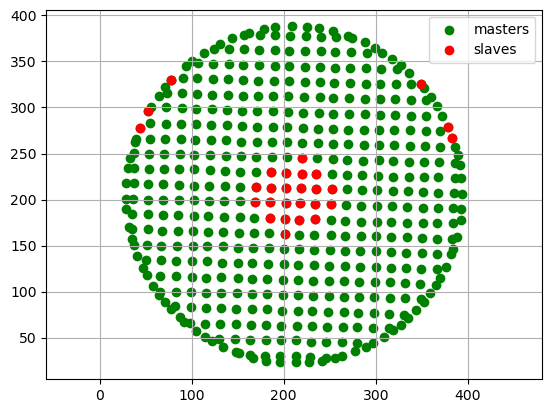

In [9]:
rIF,r_m2c = get_slaving_mat(sIF,K,zero_force=False,thr=0.2)
rIF0,r0_m2c = get_slaving_mat(sIF,K,zero_force=True,thr=0.2)
addIF,add_m2c = specula_slaving(sIF,act_coords,step=350/24,slaving_thr=0.2)

print(rIF.shape,rIF0.shape,addIF.shape,add_m2c.shape)

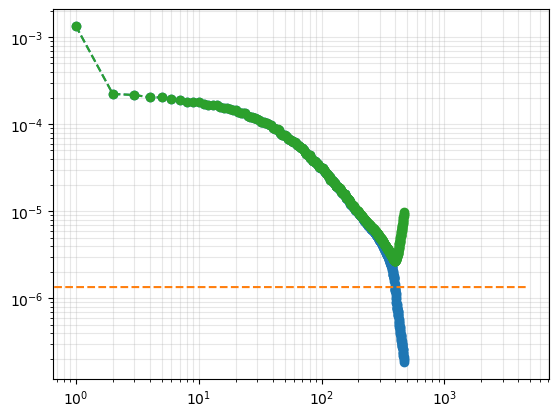

In [10]:
# Compute reconstructors
add_Rec = xp.array(np.linalg.pinv(xp.asnumpy(addIF)))
minRMS_Rec = xp.array(np.linalg.pinv(xp.asnumpy(rIF)))
zeroForce_Rec = xp.array(np.linalg.pinv(xp.asnumpy(rIF0)))
tikho_Rec = get_tikho_slaving(sIF,thr=1e-3)
unslaved_Rec = xp.array(np.linalg.pinv(xp.asnumpy(sIF)))
fullap_Rec = xp.linalg.pinv(IFs)

In [11]:
# fa_S = xp.linalg.svd(fullap_Rec,compute_uv=False)
# unslaved_S = xp.linalg.svd(unslaved_Rec,compute_uv=False)
# zeroForce_S = xp.linalg.svd(zeroForce_Rec,compute_uv=False)
# minRMS_S = xp.linalg.svd(minRMS_Rec,compute_uv=False)
# tikho_S = xp.linalg.svd(tikho_Rec,compute_uv=False)
# add_S = xp.linalg.svd(add_Rec,compute_uv=False)

In [12]:

# plt.figure()
# plt.loglog(np.arange(len(fa_S))+1,xp.asnumpy(fa_S),':',label='Full aperture')
# plt.loglog(np.arange(len(unslaved_S))+1,xp.asnumpy(unslaved_S),':',label='Unslaved')
# plt.loglog(np.arange(len(zeroForce_S))+1,xp.asnumpy(zeroForce_S),':',label='Zero force')
# plt.loglog(np.arange(len(minRMS_S))+1,xp.asnumpy(minRMS_S),':',label='Minimum RMS')
# plt.loglog(np.arange(len(tikho_S))+1,xp.asnumpy(tikho_S),':',label='Tikhonov')
# plt.loglog(np.arange(len(add_S))+1,xp.asnumpy(add_S),':',label='Added')
# plt.grid(which='both',alpha=0.3)
# plt.legend()

In [13]:
ssao = SingleStageAO(tn='ekarus')
ssao.cmask = mask.copy()
ssao.initialize_turbulence()
ssao.dm.act_coords = act_coords

Initializing devices ...
Modulating 5 [lambda/D] with 36 modulation steps
Unobscured actuators: 436/468
Fried parameter is: 5.0 [cm] (seeing = 2.02")


In [14]:
# def get_rms_res_and_cmd(phase, IF, Rec, slaving=None, K=None, remap:bool=False):
#     cmd = Rec @ phase
#     rec_phase = IF @ cmd
#     if slaving is not None:
#         cmd = slaving @ cmd
#         if K is not None:
#             cmd = K @ cmd
#     res_phase = phase - rec_phase
#     if remap is True:
#         phase_2d = reshape_on_mask(res_phase, ssao.cmask)
#         res_phase = phase_2d[~obs_mask]
#     phi_rms = xp.sqrt(xp.sum((res_phase-xp.mean(res_phase))**2)/len(res_phase))
#     cmd_rms = xp.sqrt(xp.mean(cmd**2))
#     max_cmd = xp.max(abs(cmd))
#     return phi_rms, cmd_rms, max_cmd


def get_rms_res_and_cmd(phase, Rec, slaving=None, K=None, remap=False):
    cmd = Rec @ phase
    if slaving is not None:
        cmd = slaving @ cmd
        if K is not None:
            cmd = K @ cmd
    rec_phase = IFs @ cmd
    if remap is True:
        res_phase = phase - rec_phase
        phase_2d = reshape_on_mask(res_phase, ssao.cmask)
        res_phase = phase_2d[~obs_mask]
    else:
        phase_2d = reshape_on_mask(rec_phase, ssao.cmask)
        rec_phase = phase_2d[~obs_mask]
        res_phase = phase - rec_phase
    phi_rms = xp.std(res_phase)
    cmd_rms = xp.sqrt(xp.mean(cmd**2))
    max_cmd = xp.max(abs(cmd))
    return phi_rms, cmd_rms, max_cmd

In [15]:
N = 600
step = 2

phase_rms = xp.zeros(N)

fa_rms = xp.zeros(N) # FULL APERTURE
tikho_rms = xp.zeros(N) # tikhonov regularization
add_rms = xp.zeros(N) # ADDing slave IFFs to masters'
minRMS_rms = xp.zeros(N) # minimum RMS slaving
zeroForce_rms = xp.zeros(N) # zero-force slaving

fa_cmd_rms = xp.zeros(N) # FULL APERTURE
tikho_cmd_rms = xp.zeros(N) # tikhonov regularization
add_cmd_rms = xp.zeros(N) # ADDing slave IFFs to masters'
minRMS_cmd_rms = xp.zeros(N) # minimum RMS slaving
zeroForce_cmd_rms = xp.zeros(N) # zero-force slaving

fa_max_cmd = xp.zeros(N) # FULL APERTURE
tikho_max_cmd = xp.zeros(N) # tikhonov regularization
add_max_cmd = xp.zeros(N) # ADDing slave IFFs to masters'
minRMS_max_cmd = xp.zeros(N) # minimum RMS slaving
zeroForce_max_cmd = xp.zeros(N) # zero-force slaving


for jj in range(N):
    atmo_phase = ssao.get_phasescreen_at_time(jj*ssao.dt*step)
    fa_phase = atmo_phase[~mask]
    phase = atmo_phase[~obs_mask]

    fa_phase -= xp.mean(fa_phase)
    phase -= xp.mean(phase)

    phase_rms[jj] = xp.sqrt(xp.mean(phase**2))

    # # FULL APERTURE
    # fa_rms[jj], fa_cmd_rms[jj], fa_max_cmd[jj] = get_rms_res_and_cmd(fa_phase, IFs, fullap_Rec, remap=True)

    # # tikhonov regularization
    # tikho_rms[jj], tikho_cmd_rms[jj], tikho_max_cmd[jj] = get_rms_res_and_cmd(phase, sIF, tikho_Rec)

    # # ADDing slave IFFs to masters'
    # add_rms[jj], add_cmd_rms[jj], add_max_cmd[jj] = get_rms_res_and_cmd(phase, addIF, add_Rec, slaving=add_m2c)

    # # Minimum RMS slaving
    # minRMS_rms[jj], minRMS_cmd_rms[jj], minRMS_max_cmd[jj] = get_rms_res_and_cmd(phase, rIF, minRMS_Rec, slaving=r_m2c, K=K)

    # # Zero-force slaving
    # zeroForce_rms[jj], zeroForce_cmd_rms[jj], zeroForce_max_cmd[jj] = get_rms_res_and_cmd(phase, rIF0, zeroForce_Rec, slaving=r_m2c, K=K)

    # FULL APERTURE
    fa_rms[jj], fa_cmd_rms[jj], fa_max_cmd[jj] = get_rms_res_and_cmd(fa_phase, fullap_Rec, remap=True)

    # tikhonov regularization
    tikho_rms[jj], tikho_cmd_rms[jj], tikho_max_cmd[jj] = get_rms_res_and_cmd(phase, tikho_Rec)

    # ADDing slave IFFs to masters'
    add_rms[jj], add_cmd_rms[jj], add_max_cmd[jj] = get_rms_res_and_cmd(phase, add_Rec, slaving=add_m2c)

    # Minimum RMS slaving
    minRMS_rms[jj], minRMS_cmd_rms[jj], minRMS_max_cmd[jj] = get_rms_res_and_cmd(phase, minRMS_Rec, slaving=r_m2c, K=K)

    # Zero-force slaving
    zeroForce_rms[jj], zeroForce_cmd_rms[jj], zeroForce_max_cmd[jj] = get_rms_res_and_cmd(phase, zeroForce_Rec, slaving=r0_m2c, K=K)


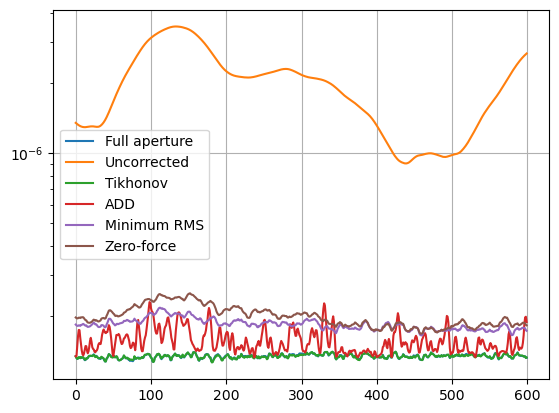

In [16]:
plt.figure()
plt.plot(xp.asnumpy(fa_rms),label='Full aperture')
plt.plot(xp.asnumpy(phase_rms),label='Uncorrected')
plt.plot(xp.asnumpy(tikho_rms),label='Tikhonov')
plt.plot(xp.asnumpy(add_rms),label='ADD')
plt.plot(xp.asnumpy(minRMS_rms),label='Minimum RMS')
plt.plot(xp.asnumpy(zeroForce_rms),label='Zero-force')
plt.grid()
plt.legend()
plt.yscale('log')

Text(0.5, 1.0, 'max command')

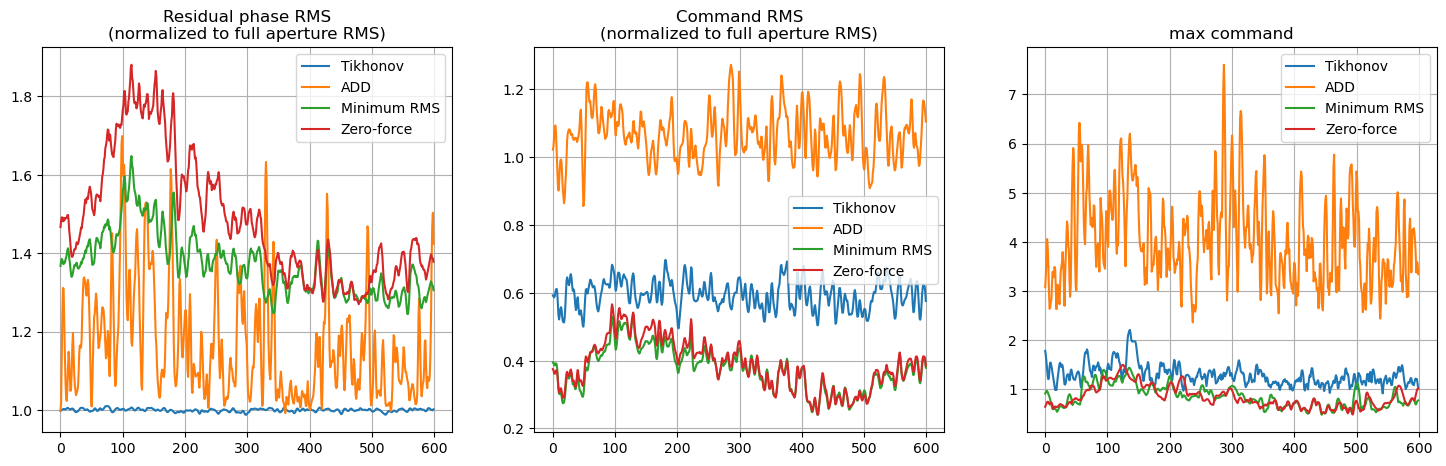

In [17]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(xp.asnumpy(tikho_rms/fa_rms),label='Tikhonov')
plt.plot(xp.asnumpy(add_rms/fa_rms),label='ADD')
plt.plot(xp.asnumpy(minRMS_rms/fa_rms),label='Minimum RMS')
plt.plot(xp.asnumpy(zeroForce_rms/fa_rms),label='Zero-force')
plt.grid()
plt.legend()
plt.title('Residual phase RMS\n(normalized to full aperture RMS)')
# plt.yscale('log')
plt.subplot(1,3,2)
plt.plot(xp.asnumpy(tikho_cmd_rms/fa_cmd_rms),label='Tikhonov')
plt.plot(xp.asnumpy(add_cmd_rms/fa_cmd_rms),label='ADD')
plt.plot(xp.asnumpy(minRMS_cmd_rms/fa_cmd_rms),label='Minimum RMS')
plt.plot(xp.asnumpy(zeroForce_cmd_rms/fa_cmd_rms),label='Zero-force')
plt.grid()
plt.legend()
plt.title('Command RMS\n(normalized to full aperture RMS)')
# plt.yscale('log')
plt.subplot(1,3,3)
# plt.plot(xp.asnumpy(fa_max_cmd),label='Full aperture')
plt.plot(xp.asnumpy(tikho_max_cmd),label='Tikhonov')
plt.plot(xp.asnumpy(add_max_cmd),label='ADD')
plt.plot(xp.asnumpy(minRMS_max_cmd),label='Minimum RMS')
plt.plot(xp.asnumpy(zeroForce_max_cmd),label='Zero-force')
plt.grid()
plt.legend()
plt.title('max command')

(np.float64(10.75), np.float64(412.25), np.float64(4.75), np.float64(406.25))

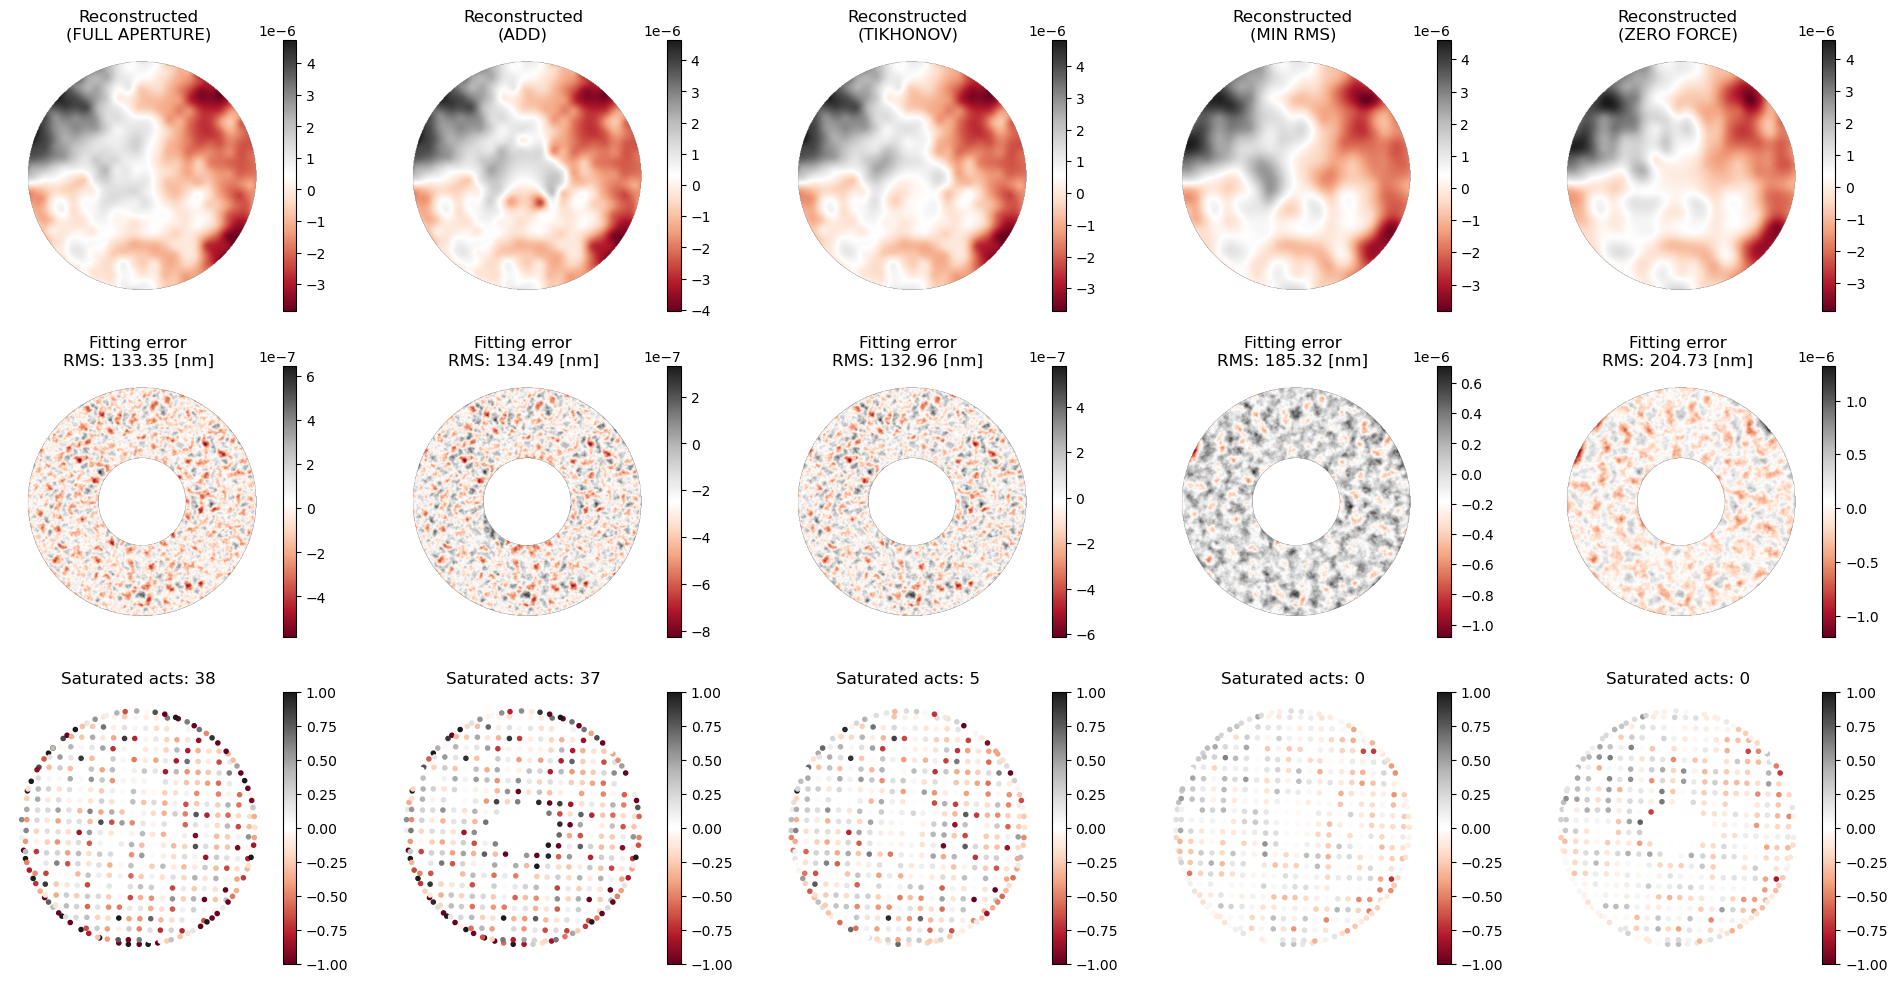

In [18]:
atmo_phase = ssao.get_phasescreen_at_time(0.1)
fa_phase = atmo_phase[~mask]
phase = atmo_phase[~obs_mask]

fa_phase -= xp.mean(fa_phase)
phase -= xp.mean(phase)

# FULL APERTURE
fa_cmd = fullap_Rec @ fa_phase
rec_phase = IFs @ fa_cmd

# ADD
add_cmd = add_m2c @ add_Rec @ phase
add_rec_phase = IFs @ add_cmd#(add_cmd-xp.mean(add_cmd))

# tikhonov
tic_cmd = tikho_Rec @ phase
tic_rec_phase = IFs @ tic_cmd

# minimum RMS
minRMS_cmd = K @ r_m2c @ minRMS_Rec @ phase
minRMS_rec_phase = IFs @ minRMS_cmd#(minRMS_cmd-xp.mean(minRMS_cmd))

# zero-force
zeroForce_cmd = K @ r0_m2c @ zeroForce_Rec @ phase
zeroForce_rec_phase = IFs @ zeroForce_cmd#(zeroForce_cmd-xp.mean(zeroForce_cmd))


fa_phase = reshape_on_mask(fa_phase, mask)
phase = reshape_on_mask(phase, obs_mask)
add_rec_phase = reshape_on_mask(add_rec_phase, mask)
tic_rec_phase = reshape_on_mask(tic_rec_phase, mask)
minRMS_rec_phase = reshape_on_mask(minRMS_rec_phase, mask)
zeroForce_rec_phase = reshape_on_mask(zeroForce_rec_phase, mask)
rec_phase = reshape_on_mask(rec_phase, ssao.cmask)

plt.figure(figsize=(24,12))
plt.subplot(3,5,1)
plt.imshow(masked_array(xp.asnumpy(rec_phase),mask=xp.asnumpy(ssao.cmask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Reconstructed\n(FULL APERTURE)')
plt.subplot(3,5,2)
plt.imshow(masked_array(xp.asnumpy(add_rec_phase),mask=xp.asnumpy(mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Reconstructed\n(ADD)')
plt.subplot(3,5,3)
plt.imshow(masked_array(xp.asnumpy(tic_rec_phase),mask=xp.asnumpy(mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Reconstructed\n(TIKHONOV)')
plt.subplot(3,5,4)
plt.imshow(masked_array(xp.asnumpy(minRMS_rec_phase),mask=xp.asnumpy(mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Reconstructed\n(MIN RMS)')
plt.subplot(3,5,5)
plt.imshow(masked_array(xp.asnumpy(zeroForce_rec_phase),mask=xp.asnumpy(mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Reconstructed\n(ZERO FORCE)')

plt.subplot(3,5,6)
plt.imshow(masked_array(xp.asnumpy(rec_phase-fa_phase),mask=xp.asnumpy(obs_mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Fitting error\nRMS: {:.2f} [nm]'.format(xp.std(rec_phase[~obs_mask]-phase[~obs_mask])*1e+9))
plt.subplot(3,5,7)
plt.imshow(masked_array(xp.asnumpy(add_rec_phase-phase),mask=xp.asnumpy(obs_mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Fitting error\nRMS: {:.2f} [nm]'.format(xp.std(add_rec_phase[~obs_mask]-phase[~obs_mask])*1e+9))
plt.subplot(3,5,8)
plt.imshow(masked_array(xp.asnumpy(tic_rec_phase-phase),mask=xp.asnumpy(obs_mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Fitting error\nRMS: {:.2f} [nm]'.format(xp.std(tic_rec_phase[~obs_mask]-phase[~obs_mask])*1e+9))
plt.subplot(3,5,9)
plt.imshow(masked_array(xp.asnumpy(minRMS_rec_phase-phase),mask=xp.asnumpy(obs_mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Fitting error\nRMS: {:.2f} [nm]'.format(xp.std(minRMS_rec_phase[~obs_mask]-phase[~obs_mask])*1e+9))
plt.subplot(3,5,10)
plt.imshow(masked_array(xp.asnumpy(zeroForce_rec_phase-phase),mask=xp.asnumpy(obs_mask)),origin='lower',cmap='RdGy')
plt.colorbar()
plt.axis('off')
plt.title('Fitting error\nRMS: {:.2f} [nm]'.format(xp.std(zeroForce_rec_phase[~obs_mask]-phase[~obs_mask])*1e+9))

plt.subplot(3,5,11)
ssao.dm.plot_position(fa_cmd,vmin=-1,vmax=1,transpose=False)
plt.title(f'Saturated acts: {xp.sum(abs(fa_cmd)>1.0):1.0f}')
plt.axis('off')
plt.subplot(3,5,12)
ssao.dm.plot_position(add_cmd,vmin=-1,vmax=1,transpose=False)
plt.title(f'Saturated acts: {xp.sum(abs(add_cmd)>1.0):1.0f}')
plt.axis('off')
plt.subplot(3,5,13)
ssao.dm.plot_position(tic_cmd,vmin=-1,vmax=1,transpose=False) #xp.dot(spe_cmd,specula_m2c.T),transpose=False)
plt.title(f'Saturated acts: {xp.sum(abs(tic_cmd)>1.0):1.0f}')
plt.axis('off')
plt.subplot(3,5,14)
ssao.dm.plot_position(minRMS_cmd,vmin=-1,vmax=1,transpose=False)
plt.title(f'Saturated acts: {xp.sum(abs(minRMS_cmd)>1.0):1.0f}')
plt.axis('off')
plt.subplot(3,5,15)
ssao.dm.plot_position(zeroForce_cmd,vmin=-1,vmax=1,transpose=False)
plt.title(f'Saturated acts: {xp.sum(abs(zeroForce_cmd)>1.0):1.0f}')
plt.axis('off')